**CNN**

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras import layers, models, callbacks

In [2]:
np.random.seed(42)
tf.random.set_seed(42)


In [3]:
data_dir = "liver_data"
healthy_dir = os.path.join(data_dir, "healthy")
cirrhosis_dir = os.path.join(data_dir, "cirrhosis")
os.makedirs(healthy_dir, exist_ok=True)
os.makedirs(cirrhosis_dir, exist_ok=True)

def generate_synthetic_image(image_path, label):
    img_size = (128, 128)
    img = Image.new('L', img_size, "white")  # Grayscale
    draw = ImageDraw.Draw(img)

    if label == "cirrhosis":
        for _ in range(60):  # More fibrosis patterns
            x1, y1 = np.random.randint(0, 128, size=2)
            x2, y2 = np.random.randint(0, 128, size=2)
            draw.line((x1, y1, x2, y2), fill="black", width=np.random.randint(1, 3))

    # Add Gaussian noise
    img_array = np.array(img, dtype=np.uint8)
    noise = np.random.normal(0, 35, (128, 128)).astype(np.uint8)
    img_array = np.clip(img_array - noise, 0, 255)

    # Save image
    Image.fromarray(img_array).save(image_path)

# Generate dataset (1000 images each)
num_images = 1000
for i in range(num_images):
    generate_synthetic_image(f"{healthy_dir}/healthy_{i}.png", "healthy")
    generate_synthetic_image(f"{cirrhosis_dir}/cirrhosis_{i}.png", "cirrhosis")

In [4]:
def load_images(data_dir, label):
    images, labels = [], []
    for img_name in os.listdir(data_dir):
        img_path = os.path.join(data_dir, img_name)
        img = Image.open(img_path).resize((128, 128))
        images.append(np.array(img) / 255.0)  # Normalize
        labels.append(label)
    return np.array(images), np.array(labels)

# Load images
healthy_images, healthy_labels = load_images(healthy_dir, 0)  # 0 = Healthy
cirrhosis_images, cirrhosis_labels = load_images(cirrhosis_dir, 1)  # 1 = Cirrhosis

# Merge datasets
X = np.concatenate([healthy_images, cirrhosis_images], axis=0)
y = np.concatenate([healthy_labels, cirrhosis_labels], axis=0)

# Reshape for CNN input
X = X.reshape(-1, 128, 128, 1)

# Apply SMOTE Oversampling to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X.reshape(len(X), -1), y)
X = X_resampled.reshape(-1, 128, 128, 1)
y = y_resampled

# Split dataset properly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"✅ Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

✅ Training samples: 1600, Testing samples: 400


In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile model
class_weights = {0: 1.2, 1: 1.0}  # Give slight weight to Healthy class
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [7]:
# Learning rate scheduler & early stopping
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train model
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test),
                    batch_size=32, callbacks=[lr_scheduler, early_stopping], verbose=2)

Epoch 1/50
50/50 - 14s - 288ms/step - accuracy: 0.5763 - loss: 1.3929 - val_accuracy: 0.5025 - val_loss: 0.7888 - learning_rate: 3.0000e-04
Epoch 2/50
50/50 - 3s - 54ms/step - accuracy: 0.7350 - loss: 0.5651 - val_accuracy: 0.5025 - val_loss: 3.1731 - learning_rate: 3.0000e-04
Epoch 3/50
50/50 - 3s - 51ms/step - accuracy: 0.7694 - loss: 0.4996 - val_accuracy: 0.5025 - val_loss: 6.4095 - learning_rate: 3.0000e-04
Epoch 4/50
50/50 - 2s - 45ms/step - accuracy: 0.7656 - loss: 0.5020 - val_accuracy: 0.5025 - val_loss: 11.0644 - learning_rate: 3.0000e-04
Epoch 5/50
50/50 - 2s - 49ms/step - accuracy: 0.7644 - loss: 0.4821 - val_accuracy: 0.5025 - val_loss: 8.8958 - learning_rate: 3.0000e-04
Epoch 6/50

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
50/50 - 2s - 44ms/step - accuracy: 0.7969 - loss: 0.4632 - val_accuracy: 0.5025 - val_loss: 4.7064 - learning_rate: 3.0000e-04
Epoch 7/50
50/50 - 2s - 43ms/step - accuracy: 0.7800 - loss: 0.4694 - val_accuracy: 0.5275 -

✅ Synthetic dataset created successfully!
✅ Training samples: 1600, Testing samples: 400


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50/50 - 8s - 151ms/step - accuracy: 0.5431 - loss: 1.4814 - val_accuracy: 0.5025 - val_loss: 0.8250 - learning_rate: 3.0000e-04
Epoch 2/50
50/50 - 2s - 44ms/step - accuracy: 0.6306 - loss: 0.6446 - val_accuracy: 0.4975 - val_loss: 0.7082 - learning_rate: 3.0000e-04
Epoch 3/50
50/50 - 3s - 50ms/step - accuracy: 0.7394 - loss: 0.5340 - val_accuracy: 0.5025 - val_loss: 1.0024 - learning_rate: 3.0000e-04
Epoch 4/50
50/50 - 3s - 51ms/step - accuracy: 0.7800 - loss: 0.4994 - val_accuracy: 0.5025 - val_loss: 2.5123 - learning_rate: 3.0000e-04
Epoch 5/50
50/50 - 3s - 50ms/step - accuracy: 0.7625 - loss: 0.5045 - val_accuracy: 0.5025 - val_loss: 3.6267 - learning_rate: 3.0000e-04
Epoch 6/50
50/50 - 3s - 53ms/step - accuracy: 0.7725 - loss: 0.4853 - val_accuracy: 0.5025 - val_loss: 1.6618 - learning_rate: 3.0000e-04
Epoch 7/50
50/50 - 2s - 49ms/step - accuracy: 0.7788 - loss: 0.4655 - val_accuracy: 0.7500 - val_loss: 0.5200 - learning_rate: 3.0000e-04
Epoch 8/50
50/50 - 3s - 50ms/step

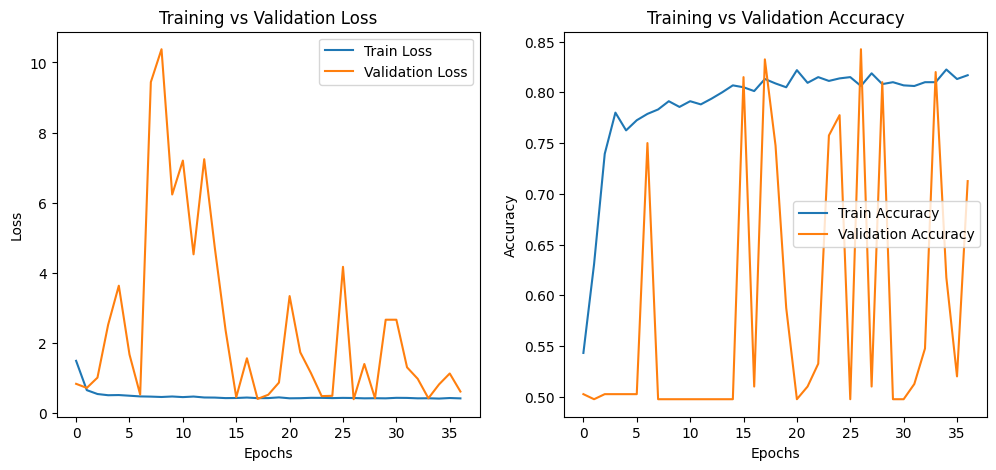

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


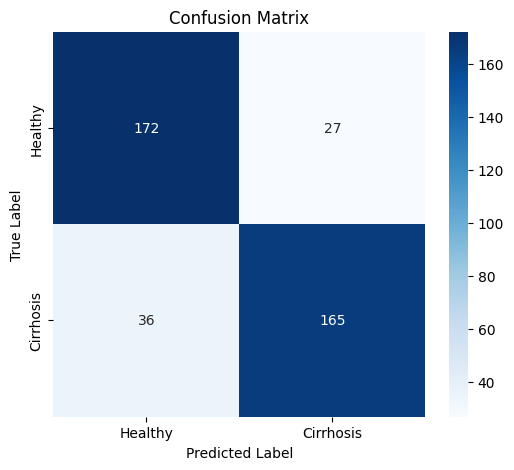

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.83      0.86      0.85       199
   Cirrhosis       0.86      0.82      0.84       201

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



In [ ]:

#  Evaluate Model with Visualizations
# ----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n✅ Model Test Accuracy: {test_acc * 100:.2f}%")

# Plot training history
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

# Compute confusion matrix
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cirrhosis'], yticklabels=['Healthy', 'Cirrhosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
class_report = classification_report(y_test, y_pred, target_names=['Healthy', 'Cirrhosis'])
print("Classification Report:\n", class_report)
